# Disease Image Classifier
**Transfer learning with PyTorch — binary classification (positive / negative for PrPsc staining)**

## Before you start
Your image folder must be arranged like this:
```
data/
  train/
    positive/   ← disease images for training
    negative/   ← healthy images for training
  val/
    positive/   ← disease images for validation
    negative/   ← healthy images for validation
```
A good split for images: put ~80% in `train/` and ~20% in `val/`.
Since there are fewer negative control images overall, make sure the `train/` directory has an equal number of images in `positive/` and `negative/` so that training is balanced.
The images can be any size — the code will resize them to be uniform for model training.

## Cell 1 — Install / import libraries
Run this first. PyTorch and torchvision should already be installed in your environment.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time, copy

# Check that the GPU is visible — should print something like "cuda:0  Tesla V100"
# if GPU is not available, CPU will be used
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU name:', torch.cuda.get_device_name(0))

Using device: cpu


## Cell 2 — Configuration
**Edit the settings here.** Everything else in the notebook reads from this cell.

In [5]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────

DATA_DIR   = Path('/pl/active/courses/2026_summer/CSU_qCMB/chronic_time_wasting_disease/data')        # path to your data/ folder
MODEL_SAVE = Path('/pl/active/courses/2026_summer/CSU_qCMB/chronic_time_wasting_disease/best_model.pth')  # where to save the trained weights

IMG_SIZE   = 224    # pixels — 224 is standard for ResNet; change if your images are tiny
BATCH_SIZE = 16     # reduce to 8 if you get 'out of memory' errors
NUM_EPOCHS = 20     # 15–25 is usually enough for transfer learning on small datasets
LEARNING_RATE = 1e-4  # small LR works well when fine-tuning a pre-trained model

# ── CLASS NAMES must match your folder names, in alphabetical order ─────────
# torchvision reads folders alphabetically, so this should be ['negative', 'positive']
# Verify below in Cell 3 — it will print the order it detected.
CLASS_NAMES = ['negative', 'positive']

## Cell 3 — Load data
This cell:
- Resizes every image to the same square (IMG_SIZE × IMG_SIZE)
- Normalises pixel values so they match what the pre-trained model expects (ResNet-18) 
- Applies light **data augmentation** to training images (random flips/rotation)
  — a useful trick to squeeze more signal out of a small dataset
- Wraps everything in `DataLoader` objects that feed batches to the GPU (if using GPU)

In [6]:
# ImageNet mean/std — required because we're using a pre-trained ImageNet model
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

data_transforms = {
    # Training: augment to help generalise
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),   # resize to square
        transforms.RandomHorizontalFlip(),         # randomly mirror left↔right
        transforms.RandomRotation(15),             # rotate up to ±15°
        transforms.ColorJitter(brightness=0.2,
                               contrast=0.2),      # slight brightness / contrast shift
        transforms.ToTensor(),                     # convert to PyTorch tensor
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    # Validation: no augmentation — we want a fair measurement
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

image_datasets = {
    split: datasets.ImageFolder(DATA_DIR / split, data_transforms[split])
    for split in ['train', 'val']
}

dataloaders = {
    split: DataLoader(image_datasets[split],
                      batch_size=BATCH_SIZE,
                      shuffle=(split == 'train'),  # shuffle training data each epoch
                      num_workers=4)               # parallel workers; lower to 0 if errors
    for split in ['train', 'val']
}

dataset_sizes = {split: len(image_datasets[split]) for split in ['train', 'val']}
detected_classes = image_datasets['train'].classes   # what torchvision found

print('Dataset sizes :', dataset_sizes)
print('Classes found :', detected_classes)
print()
print('⚠  Make sure the order above matches CLASS_NAMES =', CLASS_NAMES)
print('   If not, update CLASS_NAMES in Cell 2 to match.')

Dataset sizes : {'train': 228, 'val': 456}
Classes found : ['negative', 'positive']

⚠  Make sure the order above matches CLASS_NAMES = ['negative', 'positive']
   If not, update CLASS_NAMES in Cell 2 to match.


## Cell 4 — Preview a batch
Quick sanity check: visualise 8 training images with their labels.
If labels look wrong, revisit your folder structure.

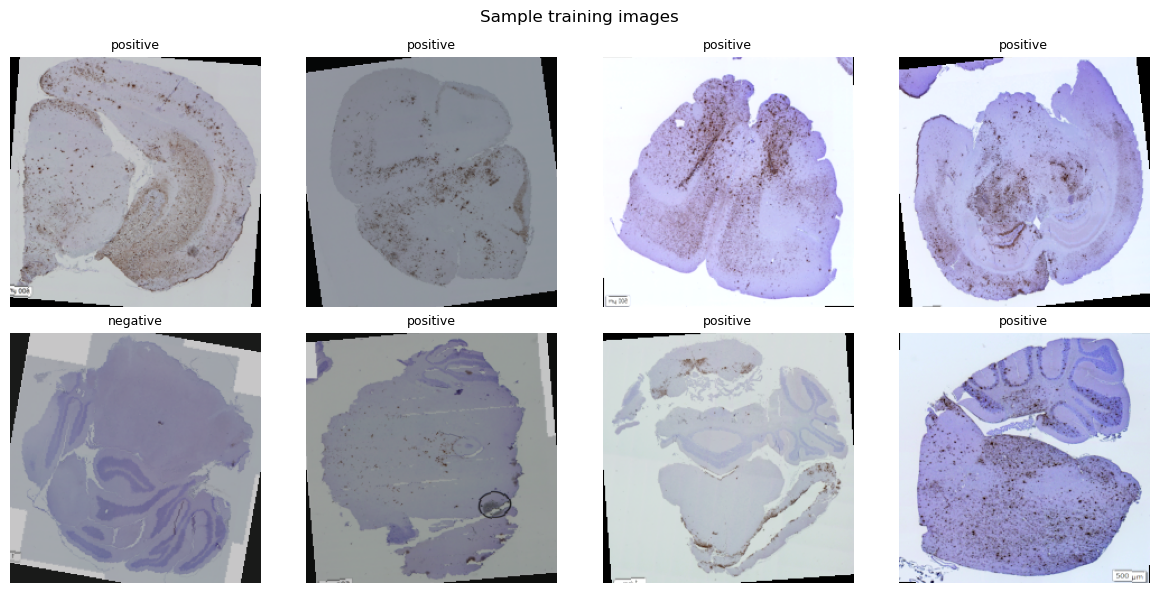

In [7]:
def imshow(tensor, title=None):
    """Undo normalisation and show a tensor as an image."""
    img = tensor.numpy().transpose((1, 2, 0))      # C×H×W → H×W×C
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)   # un-normalise
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title, fontsize=9)
    plt.axis('off')

images, labels = next(iter(dataloaders['train']))   # grab one batch
n = min(8, len(images))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < n:
        plt.sca(ax)
        imshow(images[i], title=CLASS_NAMES[labels[i]])
plt.suptitle('Sample training images', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 5 — Build the model
We use **ResNet-18**, a small but effective convolutional neural network pre-trained on 1.2 million
ImageNet photos. It already knows edges, textures, shapes — we just replace its final layer
with a 2-class output and teach it the difference between your positive/negative images.

This is called **transfer learning** and it's why ~200 images is enough for training.

In [8]:
# Load ResNet-18 pre-trained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers — we only want to re-train the final classifier at first
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer with one that outputs 2 scores
# (one per class: negative / positive)
num_features = model.fc.in_features          # 512 for ResNet-18
model.fc = nn.Linear(num_features, 2)        # this layer is un-frozen by default

model = model.to(device)                     # move to GPU

print('Model ready.')
print(f'Trainable parameters: '
      f'{sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print('(Only the final layer is being trained on the first pass.)')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/cgeer@colostate.edu/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Model ready.
Trainable parameters: 1,026
(Only the final layer is being trained on the first pass.)


## Cell 6 — Define loss function and optimiser

In [9]:
# CrossEntropyLoss is the standard loss for classification
criterion = nn.CrossEntropyLoss()

# Adam optimiser — only pass parameters that have requires_grad=True
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

# Learning-rate scheduler: reduce LR by 10× every 7 epochs
# Helps squeeze out a bit more accuracy in later epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print('Criterion, optimizer, and scheduler ready.')

Criterion, optimizer, and scheduler ready.


## Cell 7 — Training loop
This is the core of the notebook. Each **epoch** loops over all training images once,
updates the model weights, then measures accuracy on the validation set.
The best weights (highest val accuracy) are saved automatically.

In [10]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc       = 0.0
    history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1:02d}/{num_epochs}  ', end='')
        t0 = time.time()

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss    = 0.0
            running_correct = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()  # clear gradients from previous batch

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)                          # forward pass
                    _, preds = torch.max(outputs, 1)                 # predicted class
                    loss = criterion(outputs, labels)                # compute loss

                    if phase == 'train':
                        loss.backward()   # backpropagation
                        optimizer.step()  # update weights

                running_loss    += loss.item() * inputs.size(0)
                running_correct += (preds == labels).sum().item()

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss    / dataset_sizes[phase]
            epoch_acc  = running_correct / dataset_sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f'{phase} loss={epoch_loss:.3f} acc={epoch_acc:.3f}  ', end='')

            # Save the best model based on validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc       = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print(f'({time.time()-t0:.0f}s)')

    print(f'\nTraining complete. Best val accuracy: {best_acc:.4f}')
    torch.save(best_model_wts, MODEL_SAVE)
    print(f'Best weights saved to {MODEL_SAVE}')

    model.load_state_dict(best_model_wts)   # restore best weights into the model
    return model, history


print('Starting training...')
model, history = train_model(model, criterion, optimizer, scheduler, NUM_EPOCHS)

Starting training...
Epoch 01/20  train loss=0.730 acc=0.526  val loss=0.680 acc=0.561  (20s)
Epoch 02/20  train loss=0.640 acc=0.645  val loss=0.585 acc=0.726  (17s)
Epoch 03/20  train loss=0.615 acc=0.671  val loss=0.634 acc=0.658  (16s)
Epoch 04/20  train loss=0.585 acc=0.711  val loss=0.579 acc=0.746  (16s)
Epoch 05/20  train loss=0.537 acc=0.807  val loss=0.618 acc=0.671  (16s)
Epoch 06/20  train loss=0.530 acc=0.816  val loss=0.487 acc=0.840  (16s)
Epoch 07/20  train loss=0.478 acc=0.882  val loss=0.543 acc=0.770  (17s)
Epoch 08/20  train loss=0.455 acc=0.882  val loss=0.545 acc=0.761  (16s)
Epoch 09/20  train loss=0.488 acc=0.838  val loss=0.510 acc=0.809  (16s)
Epoch 10/20  train loss=0.462 acc=0.877  val loss=0.528 acc=0.776  (16s)
Epoch 11/20  train loss=0.455 acc=0.908  val loss=0.518 acc=0.787  (17s)
Epoch 12/20  train loss=0.478 acc=0.829  val loss=0.515 acc=0.796  (16s)
Epoch 13/20  train loss=0.459 acc=0.886  val loss=0.516 acc=0.787  (16s)
Epoch 14/20  train loss=0.466 

## Cell 8 — Plot training curves
Two plots: loss (lower is better) and accuracy (higher is better).

**What to look for:**
- If val accuracy is much lower than train accuracy → the model is overfitting (memorising training data). Try more augmentation or fewer epochs.
- If both are low → the model is underfitting. Try unfreezing more layers (Cell 9).

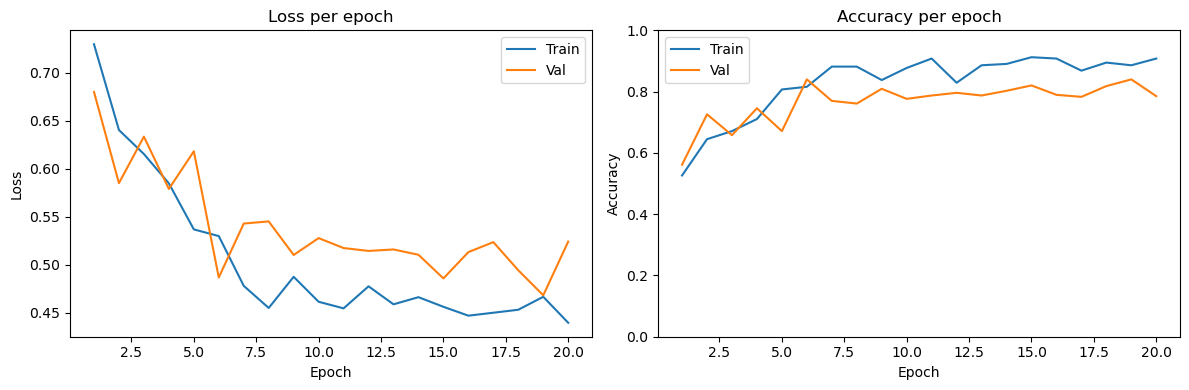

In [11]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.set_title('Loss per epoch');  ax1.set_xlabel('Epoch');  ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Val')
ax2.set_title('Accuracy per epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1]); ax2.legend()

plt.tight_layout()
plt.show()

## Cell 9 — (Optional) Fine-tune the whole network
If accuracy is still not great after Cell 7, run this cell to **unfreeze all layers**
and continue training with a very small learning rate.

This lets the earlier convolutional layers adapt to the specific visual features in your images.
It takes longer but often gives a noticeable boost.

In [12]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Use a much smaller LR so we don't destroy the pre-trained features
optimizer_ft = optim.Adam(model.parameters(), lr=1e-5)
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

print('All layers unfrozen. Fine-tuning for 10 more epochs...')
model, history_ft = train_model(model, criterion, optimizer_ft, scheduler_ft,
                                 num_epochs=10)

All layers unfrozen. Fine-tuning for 10 more epochs...
Epoch 01/10  train loss=0.414 acc=0.873  val loss=0.282 acc=0.921  (24s)
Epoch 02/10  train loss=0.255 acc=0.952  val loss=0.202 acc=0.945  (23s)
Epoch 03/10  train loss=0.168 acc=0.974  val loss=0.157 acc=0.954  (23s)
Epoch 04/10  train loss=0.135 acc=0.969  val loss=0.119 acc=0.963  (23s)
Epoch 05/10  train loss=0.092 acc=0.987  val loss=0.116 acc=0.961  (23s)
Epoch 06/10  train loss=0.078 acc=0.982  val loss=0.124 acc=0.956  (23s)
Epoch 07/10  train loss=0.088 acc=0.987  val loss=0.103 acc=0.965  (23s)
Epoch 08/10  train loss=0.106 acc=0.978  val loss=0.132 acc=0.956  (23s)
Epoch 09/10  train loss=0.089 acc=0.978  val loss=0.104 acc=0.965  (23s)
Epoch 10/10  train loss=0.088 acc=0.982  val loss=0.117 acc=0.958  (23s)

Training complete. Best val accuracy: 0.9649
Best weights saved to /projects/cgeer@colostate.edu/hackathon/best_model.pth


## Cell 10 — Evaluate on validation set
Computes a full **confusion matrix** and prints precision / recall / F1.

For a disease classifier, **recall** (sensitivity) is usually the most important metric:
it measures how many real positive cases you correctly caught.

              precision    recall  f1-score   support

    negative       0.64      1.00      0.78        29
    positive       1.00      0.96      0.98       427

    accuracy                           0.96       456
   macro avg       0.82      0.98      0.88       456
weighted avg       0.98      0.96      0.97       456



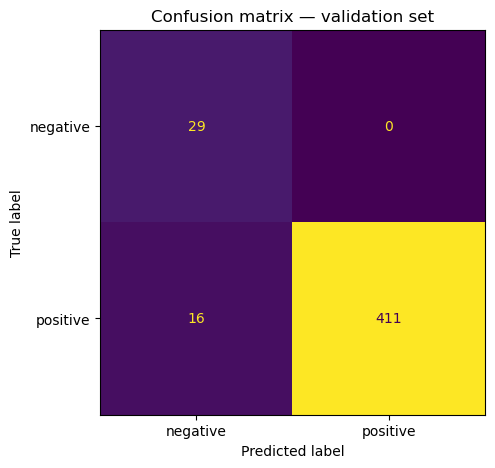

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False)
plt.title('Confusion matrix — validation set')
plt.show()

## Cell 11 — Predict on a new image
Point `IMAGE_PATH` at any image file to get a prediction.

In [ ]:
from PIL import Image

IMAGE_PATH = 'data/val/positive/some_image.jpg'  # ← change this

# Same preprocessing as validation (no augmentation)
preprocess = data_transforms['val']

img = Image.open(IMAGE_PATH).convert('RGB')
tensor = preprocess(img).unsqueeze(0).to(device)   # add batch dimension

model.eval()
with torch.no_grad():
    outputs  = model(tensor)
    probs    = torch.softmax(outputs, dim=1)[0]    # convert to probabilities
    pred_idx = probs.argmax().item()

print(f'Prediction : {CLASS_NAMES[pred_idx]}')
print(f'Confidence : {probs[pred_idx]:.1%}')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {probs[i]:.1%}')

plt.imshow(img)
plt.title(f'{CLASS_NAMES[pred_idx]}  ({probs[pred_idx]:.1%})', fontsize=12)
plt.axis('off')
plt.show()

## Cell 12 — Load saved model later
If you close the notebook and want to reload the trained model without re-training:

In [ ]:
# Re-create the same architecture, then load weights
model_loaded = models.resnet18(weights=None)       # don't download ImageNet weights again
model_loaded.fc = nn.Linear(model_loaded.fc.in_features, 2)
model_loaded.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
model_loaded = model_loaded.to(device)
model_loaded.eval()
print('Model loaded from', MODEL_SAVE)